<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Setup environment

## Setup imports

In [ ]:
from monai.utils import set_determinism

from monai.config import print_config
from monai.networks.nets.restormer import Restormer
from monai.apps import MedNISTDataset

import os
import torch
import matplotlib.pyplot as plt
import tempfile
import pandas as pd
from fastai.vision.all import OptimWrapper

from bioMONAI.data import *
from bioMONAI.core import *
from bioMONAI.losses import SSIMLoss
from bioMONAI.transforms import ScaleIntensity, RandGaussianSmooth, RandGaussianNoise, ApplyTo

print_config()
set_determinism(42)

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.9.1+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/<username>/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.0
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.24.1+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.0
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or

# Construct Pairwise Training Inputs for Restoration

We use the `MedNISTDataset` object to download and unzip the actual data files. We select the hand X-ray class for this demonstration.

To create training pairs suitable for an image restoration task, we structure our data dictionaries with two keys: `"original_hand"` and `"noisy_hand"`. Initially, both keys point to the same clean hand X-ray image path.

During the data loading and transformation pipeline:
1.  The `"original_hand"` image serves as the clean, high-quality target image.
2.  The `"noisy_hand"` image, initially identical to the original one, undergoes a series of **random synthetic degradations**. For this small example, we apply common degradations like Gaussian noise and Gaussian blur (smoothing) specifically to the `"noisy_hand"`. This simulates realistic scenarios where images might be corrupted by sensor noise, motion blur, or varying acquisition settings.

In [ ]:
directory = '../_data/'
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

train_data = MedNISTDataset(root_dir=root_dir, section="training", download=True, transform=None)
hand_df = pd.DataFrame([
    {"original_hand": item["image"], "noisy_hand": item["image"]}
    for item in train_data.data
    if item["label"] == 4  # label 4 is for xray hands
])
training_df = pd.concat([hand_df[:1000].assign(is_valid=0), hand_df[2000:2500].assign(is_valid=1)], ignore_index=True)
print("\nfirst training items: \n", training_df[:3])

../_data/
2026-04-07 23:45:23,708 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2026-04-07 23:45:23,709 - INFO - File exists: ../_data/MedNIST.tar.gz, skipped downloading.
2026-04-07 23:45:23,709 - INFO - Non-empty folder exists in ../_data/MedNIST, skipped extracting.


Loading dataset: 100%|██████████| 47164/47164 [00:00<00:00, 396376.78it/s]


first training items: 
                       original_hand                        noisy_hand  \
0  ../_data/MedNIST/Hand/000942.jpg  ../_data/MedNIST/Hand/000942.jpg   
1  ../_data/MedNIST/Hand/004200.jpg  ../_data/MedNIST/Hand/004200.jpg   
2  ../_data/MedNIST/Hand/003081.jpg  ../_data/MedNIST/Hand/003081.jpg   

   is_valid  
0         0  
1         0  
2         0  


In [ ]:
train_transforms =     [
        ScaleIntensity(),
        ApplyTo(RandGaussianNoise(prob=0.5, std=0.1)),
        ApplyTo(RandGaussianSmooth(prob=0.5, sigma_x=(0.5, 1.5), sigma_y=(0.5, 1.5))),
        ScaleIntensity(),
    ]

## Visualisation of the training pairs

In [ ]:
data_ops = {
    'fn_col': ['noisy_hand'],
    'target_col': ['original_hand'],
    'valid_col': ['is_valid'],
    'bs': 16,
    'item_tfms': train_transforms, 
    'shuffle': True,
}

data = BioDataLoaders.from_df(training_df, **data_ops)

# print length of training, validation, and test datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 1000 
validation images: 500


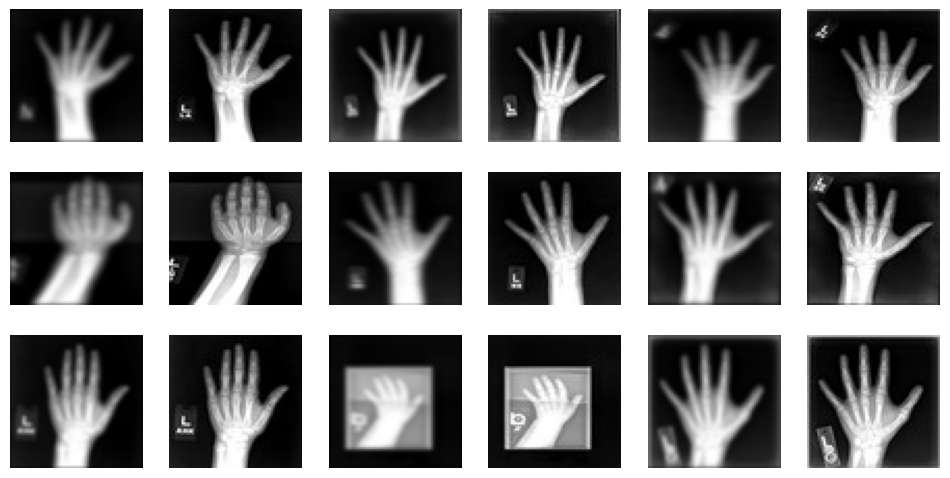

In [ ]:
data.show_batch(figsize=(12, 6))

## Create the training pipelines

We use a `CacheDataset` to capture the training pairs and accelerate the training process. The MedNISTDataset provides pairs of "noisy" and "original" images. For demonstration purposes, we treat this as an image restoration problem: the "noisy" image is a degraded version of the "original" reference image (e.g., due to simulated movement or noise). The goal is to restore the noisy image to match the original image.

## Model and Training

Now, let's initialize the Restormer model and train it to restore the noisy images. Since this is just a tutorial, we will initialize a small Restormer model with a small size configuration for quick experimentation: 

- `dim=32`: the embedding dimension (feature width) at the first stage.
- `num_blocks=[2, 2]`: 2 encoder and 2 decoder blocks.
- `num_heads=[2, 2]`: 2 attention heads at each stage.
- `refinement=1`: 1 refinement block at the bottleneck.

When training image restoration models, common regression losses include [`MSELoss`](https://deepCLEM.github.io/bioMONAI/losses.html#mseloss), `PSNRLoss`, and `SSIMLoss`. Here, we use `SSIMLoss` because it encourages the model to focus on matching the structural similarity (shape and details) of the hands, rather than just restoring absolute pixel values.

In [ ]:
import torch 
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
model = Restormer(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    dim=32,
    num_blocks=[2, 2],
    heads=[2, 2],
    num_refinement_blocks=1,
)
image_loss = SSIMLoss(spatial_dims=2)
optimizer = OptimWrapper(opt=torch.optim.Adam(model.parameters(), 1e-5))

trainer = fastTrainer(data, model, loss_fn=image_loss, metrics=[], show_summary=False, lr=1e-5, show_graph=True, optimizer=optimizer)

## The training loops

epoch,train_loss,valid_loss,time
0,0.540924,0.402517,00:05
1,0.347592,0.243856,00:05
2,0.245168,0.184494,00:05
3,0.187564,0.154350,00:05
4,0.155783,0.134314,00:04
5,0.136213,0.120692,00:04
6,0.121420,0.112226,00:04
7,0.110966,0.103617,00:04
8,0.103200,0.097754,00:04
9,0.096716,0.093013,00:04


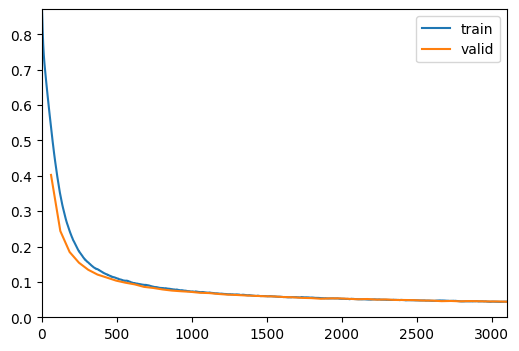

In [ ]:
max_epochs = 50

trainer.fit(max_epochs)

In [ ]:
torch.cuda.max_memory_allocated() / 1024**2

2352.78759765625

# Visualise some validation results
This section creates a set of previously unseen pairs of noisy vs original hands,
and use the network to predict the transformation between each pair.

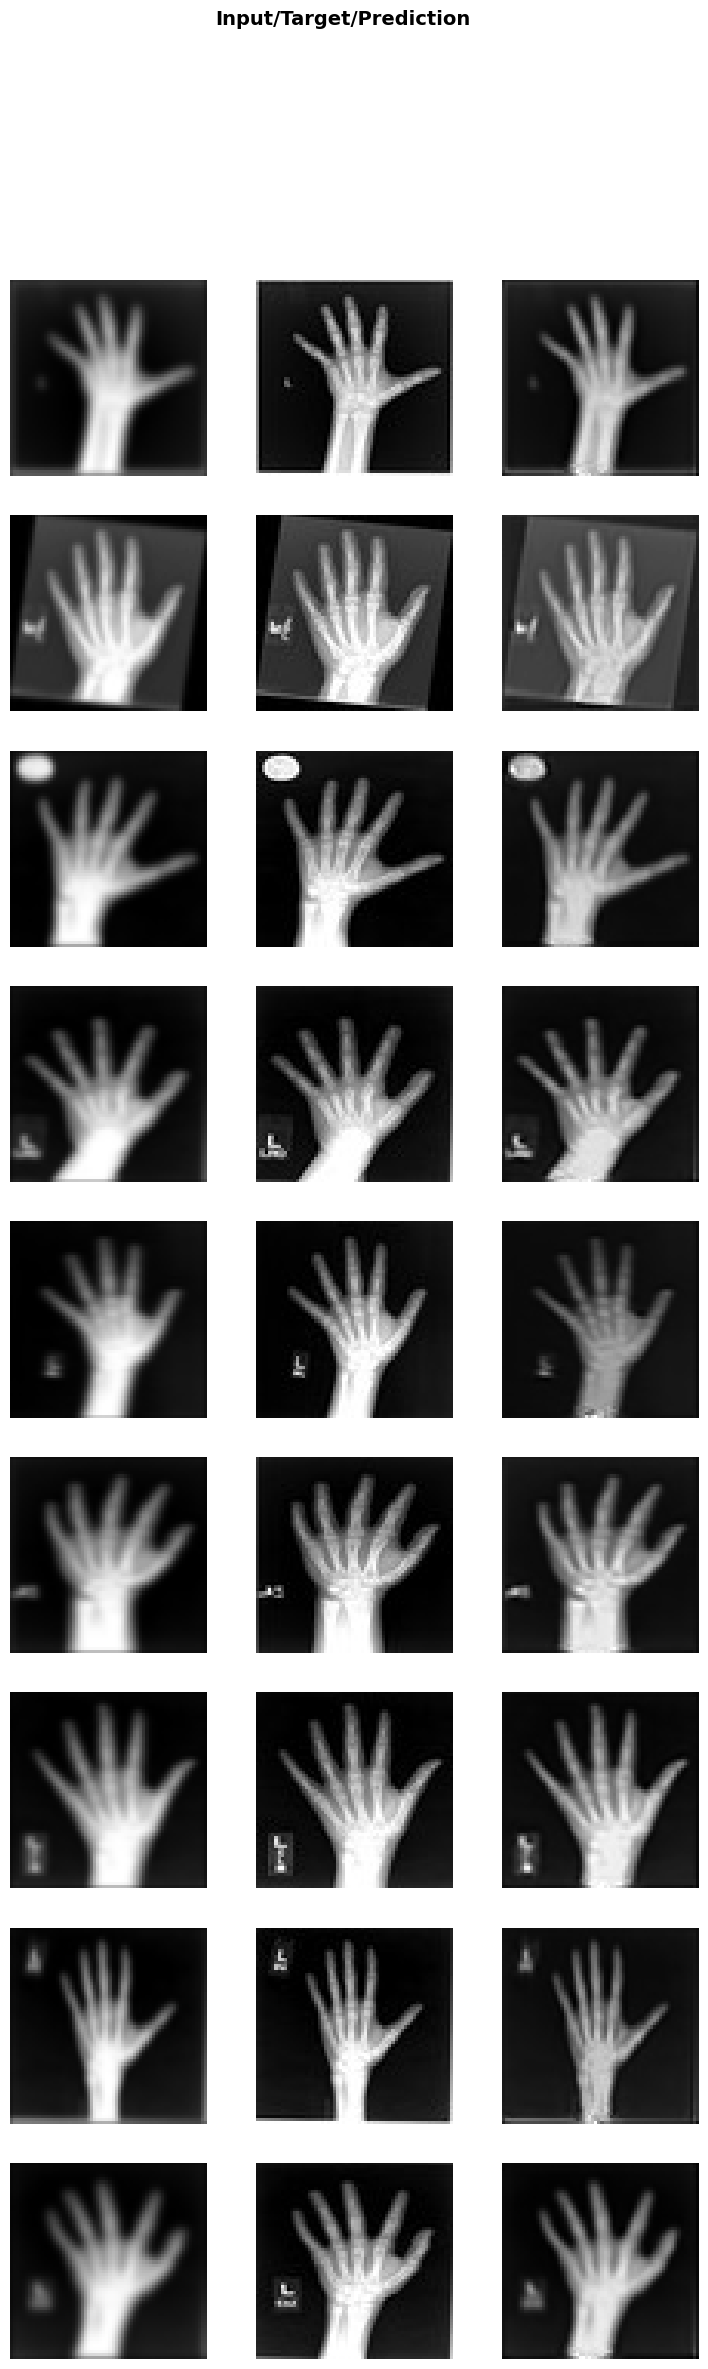

In [ ]:
trainer.show_results()